# 恶劣天气下的交通标志识别

**Traffic Sign Recognition under Adverse Weather**


## 1. 背景

### 1.1 背景介绍

交通标志是道路交通系统中传递限速、禁令、警告和指示信息的重要载体。准确识别交通标志，是自动驾驶、高级驾驶辅助系统、车路协同、道路巡检和智慧交通建设中的基础能力。

在实际道路环境中，交通标志图像可能受到雨雪天气、雾霾、夜间低照度、车灯眩光、运动模糊、局部遮挡、标志污损、图像压缩和拍摄角度变化等因素影响。部分图片中的交通标志尺寸较小、分辨率较低，进一步增加了模型识别的难度。

本赛题旨在考察参赛者对图像预处理、特征提取、模型训练和分类评估等方法的综合应用能力，以及模型在复杂环境下的泛化能力。

### 1.2 数据集展示

任务共25类，每张图片对应一个主要交通标志类别。它是图像级单标签分类，不是目标检测，不提供也不要求输出目标框。评价指标为macro F1 × 100。

### 1.3 应用场景与任务约束

当前数据规模如下：

- 训练增强集：3122张；
- 验证集：628张；
- 评分集：746张；
- 类别数量：25类。

验证集用于阶段性参考，评分集用于最终排名，二者均不向参赛者提供真实标签。

## 2. 数据集分析和可视化

### 2.1 数据目录与类别名称


训练图片按照交通标志类别存放在不同的子目录中，图片文件名采用统一格式：

`train_{class_index:02d}_{sequence:05d}.扩展名`

例如：

- `train_00_00001.jpg`
- `train_08_00001.png`
- `train_24_00121.jpg`

其中，`class_index`表示类别编号，取值范围为0～24；`sequence`表示该类别目录下的图片序号。

类别编号和正式类别名称以`classes.txt`为准。为避免目录名称中的连续空格影响类别匹配，代码会清理类别名称首尾空白，并将连续空白统一为单个空格。

例如，物理目录名称：

`dangerous curve  left traffic sign`

在程序中会规范化为正式逻辑类别：

`dangerous curve left traffic sign`

该处理只规范化空白字符，不会自动修改大小写或纠正拼写错误。

In [9]:
from pathlib import Path
from collections import Counter
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from sklearn.metrics import f1_score
MODEL_PATH = Path('/home/jovyan/work/results/model_sample.pth')
BASE_DIR = Path.cwd()
# 当前完整训练增强集（3122 张、25 类）。线上运行时改为平台实际数据集路径。
TRAIN_DIR = Path(r'/home/jovyan/work/datasets/6a55d503fdd9153745ce922b-momodel/train')
IMAGE_SIZE = 128
SEED = 42
SUPPORTED = {'.jpg', '.jpeg', '.png', '.bmp', '.webp', '.tif', '.tiff'}

def normalize_label(label):
    return ' '.join(str(label).strip().split())

mapping = {}
for line in Path('/home/jovyan/work/classes.txt').read_text(
    encoding='utf-8-sig'
).splitlines():
    if line:
        index, name = line.split('\t', 1)
        mapping[int(index)] = normalize_label(name)
CLASSES = [mapping[index] for index in range(25)]
CLASS_TO_IDX = {name: index for index, name in enumerate(CLASSES)}
if not TRAIN_DIR.is_dir():
    raise FileNotFoundError(f'训练集目录不存在：{TRAIN_DIR}')

PHYSICAL_DIRS = {normalize_label(path.name): path for path in TRAIN_DIR.iterdir() if path.is_dir()}
missing_classes = sorted(set(CLASSES) - set(PHYSICAL_DIRS))
extra_directories = sorted(set(PHYSICAL_DIRS) - set(CLASSES))
if missing_classes or extra_directories:
    raise ValueError(
        f'训练集类别目录与 classes.txt 不一致；缺少：{missing_classes}；多余：{extra_directories}'
    )
print(f'训练目录校验通过：{TRAIN_DIR}，共 {len(PHYSICAL_DIRS)} 类')


训练目录校验通过：/home/jovyan/work/datasets/6a55d503fdd9153745ce922b-momodel/train，共 25 类


### 2.2 类别数量统计与样例展示

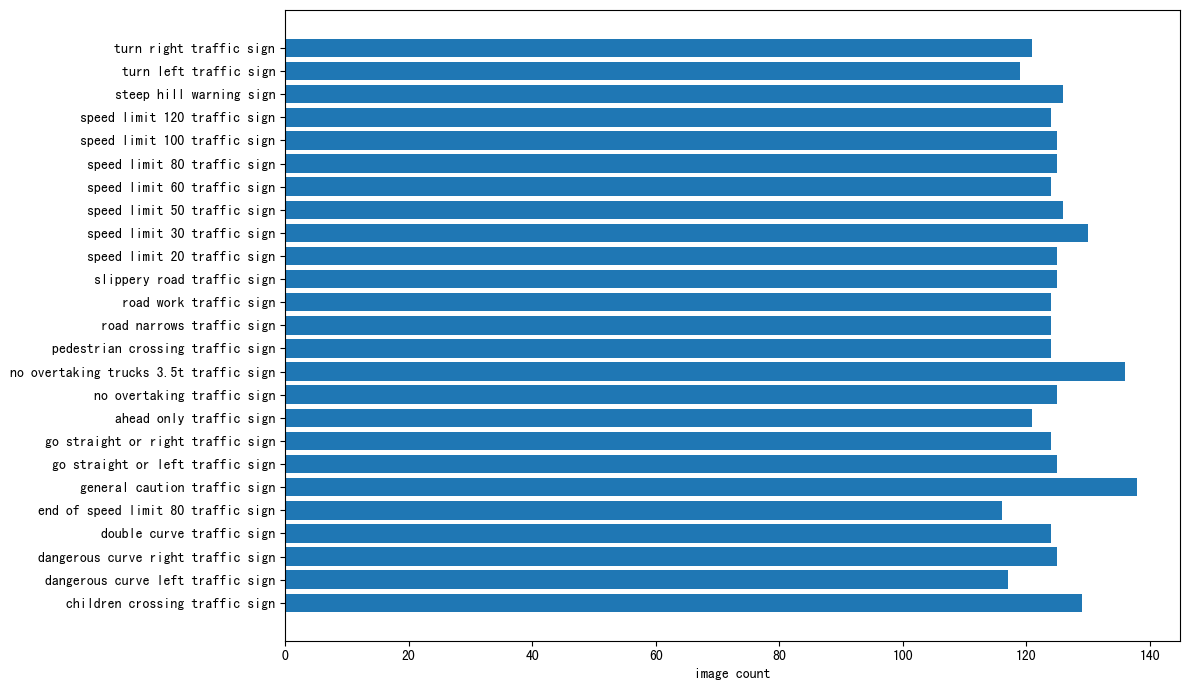

In [10]:
class_counts, samples = {}, []
for class_name in CLASSES:
    files = sorted(path for path in PHYSICAL_DIRS[class_name].iterdir()
                   if path.is_file() and path.suffix.lower() in SUPPORTED)
    class_counts[class_name] = len(files)
    samples.extend((path, CLASS_TO_IDX[class_name]) for path in files)

plt.figure(figsize=(12, 7))
plt.barh(list(class_counts), list(class_counts.values()))
plt.xlabel('image count')
plt.tight_layout()
plt.show()


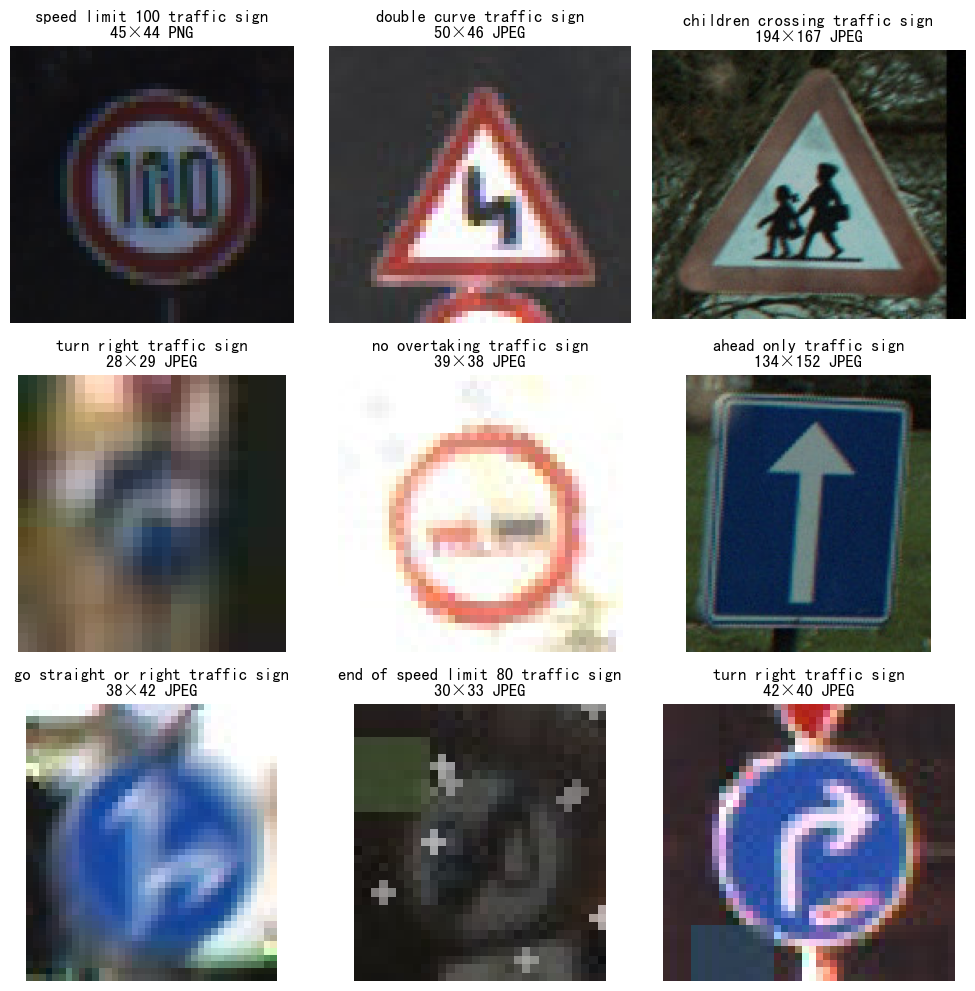

In [11]:
random.seed(SEED)
chosen = random.sample(samples, k=min(9, len(samples)))
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for axis, (path, label) in zip(axes.flat, chosen):
    with Image.open(path) as image:
        axis.imshow(image.convert('RGB'))
        axis.set_title(f'{CLASSES[label]}\n{image.width}×{image.height} {image.format}')
    axis.axis('off')
plt.tight_layout()
plt.show()


### 2.3 分辨率与退化情况

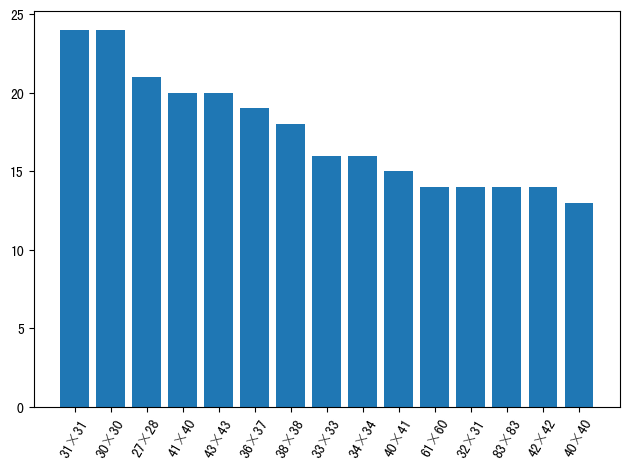

In [12]:
resolution_counts = Counter()
for path, _ in samples:
    with Image.open(path) as image:
        resolution_counts[image.size] += 1
common = resolution_counts.most_common(15)
plt.bar([f'{w}×{h}' for (w, h), _ in common], [count for _, count in common])
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()


扫描结果显示尺寸跨度为27×25至2940×1960，宽高中位数约59×58，最常见为31×31。大量图片较小，基线默认128×128；可比较96、128、160和224。训练集包含雾、雨雪、低光、模糊、压缩和遮挡等退化。

## 3. 模型构建

### 3.1 导入库函数

In [13]:
# ================== 导入所需库 ==================
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from threading import Lock

# ================== 配置路径和常量 ==================
#BASE_DIR = Path(__file__).resolve().parent          # 当前脚本所在目录
CLASSES_PATH = Path('/home/jovyan/work/classes.txt')   # 类别文件绝对路径
MODEL_PATH = Path('/home/jovyan/work/results/model_sample.pth')  # 模型文件绝对路径
NUM_CLASSES = 25
DEFAULT_INPUT_SIZE = 128
MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
STD = np.array([0.229, 0.224, 0.225], dtype=np.float32)

# ================== 工具函数 ==================
def normalize_label(label):
    '''只清理首尾空白和连续空白，不修改大小写或拼写。'''
    return ' '.join(str(label).strip().split())

def load_classes(path=CLASSES_PATH):
    """按显式编号读取稳定类别映射。"""
    indexed = {}
    with path.open('r', encoding='utf-8-sig') as file:
        for line_number, raw in enumerate(file, 1):
            line = raw.rstrip('\r\n')
            if not line:
                continue
            try:
                index_text, class_name = line.split('\t', 1)
                index = int(index_text)
            except ValueError as exc:
                raise ValueError(f'classes.txt第{line_number}行格式错误') from exc
            class_name = normalize_label(class_name)
            if index in indexed or not class_name:
                raise ValueError(f'classes.txt第{line_number}行编号重复或类别为空')
            indexed[index] = class_name
    if sorted(indexed) != list(range(NUM_CLASSES)):
        raise ValueError('classes.txt必须且只能包含连续编号0～24')
    classes = [indexed[index] for index in range(NUM_CLASSES)]
    if len(set(classes)) != NUM_CLASSES:
        raise ValueError('classes.txt规范化后存在重复类别')
    return classes

# ================== 模型定义 ==================
class TrafficSignCNN(nn.Module):
    """不依赖固定输入空间尺寸的轻量卷积分类器。"""
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.4), nn.Linear(256, num_classes)
        )

    def forward(self, inputs):
        return self.classifier(self.features(inputs))




### 3.2 数据加载以及预处理

训练和推理均采用ImageNet均值方差。默认禁止水平翻转，因为左/右转、左/右弯道和直行或左/右转类别会因翻转改变真实标签。

In [17]:
# ================== 模型加载与预测（全局缓存） ==================
_model = None
_classes = None
_input_size = DEFAULT_INPUT_SIZE
_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
_load_lock = Lock()

def _checkpoint_mapping(checkpoint, fallback):
    mapping = checkpoint.get("idx_to_class")
    if mapping is None:
        class_to_idx = checkpoint.get("class_to_idx")
        if class_to_idx is not None:
            mapping = {int(index): name for name, index in class_to_idx.items()}
    if mapping is None:
        return fallback
    if isinstance(mapping, list):
        result = [normalize_label(name) for name in mapping]
    else:
        result = [normalize_label(mapping.get(i, mapping.get(str(i)))) for i in range(NUM_CLASSES)]
    if len(result) != NUM_CLASSES or any(not isinstance(name, str) for name in result):
        raise ValueError("checkpoint 中的 idx_to_class/class_to_idx 不完整")
    if result != fallback:
        raise ValueError("checkpoint 类别顺序与 classes.txt 不一致")
    return result

def _torch_load(path):
    try:
        return torch.load(path, map_location=_device, weights_only=True)
    except TypeError:
        return torch.load(path, map_location=_device)

def _load_model_once():
    global _model, _classes, _input_size
    if _model is not None and _classes is not None:
        return _model, _classes, _input_size
    with _load_lock:
        if _model is not None and _classes is not None:
            return _model, _classes, _input_size
        if not MODEL_PATH.is_file():
            raise FileNotFoundError(
                f"未找到模型文件：{MODEL_PATH}。请确保模型已训练并放置在正确路径。"
            )
        classes = load_classes()
        checkpoint = _torch_load(MODEL_PATH)
        if isinstance(checkpoint, dict) and 'model_state_dict' not in checkpoint:
            checkpoint = {
                'model_state_dict': checkpoint,
                'num_classes': NUM_CLASSES,
                'input_size': DEFAULT_INPUT_SIZE,
            }
        if not isinstance(checkpoint, dict) or "model_state_dict" not in checkpoint:
            raise ValueError("模型文件必须是包含 model_state_dict 的完整 checkpoint")
        if int(checkpoint.get("num_classes", NUM_CLASSES)) != NUM_CLASSES:
            raise ValueError("checkpoint 的 num_classes 必须为 25")
        classes = _checkpoint_mapping(checkpoint, classes)
        input_size = checkpoint.get("input_size", DEFAULT_INPUT_SIZE)
        if isinstance(input_size, (list, tuple)):
            input_size = input_size[0]
        input_size = int(input_size)
        model = TrafficSignCNN(num_classes=NUM_CLASSES).to(_device)
        model.load_state_dict(checkpoint["model_state_dict"])
        model.eval()
        _model, _classes, _input_size = model, classes, input_size
        return model, classes, input_size

def _prepare_image(image, input_size):
    if not isinstance(image, np.ndarray) or image.size == 0:
        raise ValueError('X必须是非空np.ndarray')
    if not np.issubdtype(image.dtype, np.number):
        raise TypeError(f'不支持的图像dtype：{image.dtype}')
    if not np.isfinite(image).all():
        raise ValueError('图像包含NaN或无穷值')
    if image.ndim == 2:
        rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    elif image.ndim == 3 and image.shape[2] == 1:
        rgb = cv2.cvtColor(image[:, :, 0], cv2.COLOR_GRAY2RGB)
    elif image.ndim == 3 and image.shape[2] == 3:
        rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) if np.issubdtype(image.dtype, np.integer) else image
    elif image.ndim == 3 and image.shape[2] == 4:
        rgb = cv2.cvtColor(image, cv2.COLOR_BGRA2RGB) if np.issubdtype(image.dtype, np.integer) else image[:, :, :3]
    else:
        raise ValueError(f"不支持的图像形状：{image.shape}")
    resized = cv2.resize(rgb, (input_size, input_size), interpolation=cv2.INTER_AREA)
    normalized = resized.astype(np.float32)
    if np.issubdtype(image.dtype, np.integer):
        normalized /= float(np.iinfo(image.dtype).max)
    elif normalized.min() < 0.0 or normalized.max() > 255.0:
        raise ValueError('浮点图像值域必须在[0,1]或[0,255]')
    elif normalized.max() > 1.0:
        normalized /= 255.0
    normalized = (normalized - MEAN) / STD
    chw = np.ascontiguousarray(normalized.transpose(2, 0, 1))
    return torch.from_numpy(chw).unsqueeze(0).to(_device)

# --------------------------`predict(X)`接口会自动加载该模型  ---------------------------

def predict(X):
    """
    参数：
        X: np.ndarray，通常由cv2.imread读取，BGR格式，原始尺寸可能不一致。
    返回：
        str，25个正式交通标志类别名称之一。
    """
    model, classes, input_size = _load_model_once()
    inputs = _prepare_image(X, input_size)
    with torch.no_grad():
        class_index = int(model(inputs).argmax(dim=1).item())
    label = normalize_label(classes[class_index])
    if label not in classes:
        raise RuntimeError('模型输出不属于正式25类')
    return label


### 3.3 模型结构

本基线使用轻量级卷积神经网络`TrafficSignCNN`完成25类交通标志分类。

模型主要由以下部分组成：

- 多组卷积层，用于提取交通标志的边缘、颜色、形状和局部图案特征；
- BatchNorm层，用于稳定训练过程；
- ReLU激活函数，用于增强模型的非线性表达能力；
- 池化层，用于逐步压缩特征图；
- `AdaptiveAvgPool2d`，用于适配不同输入尺寸；
- Dropout层，用于降低过拟合风险；
- 全连接分类层，输出25个类别对应的预测结果。

模型没有使用固定的特征图展开尺寸，因此能够适配不同的输入分辨率。Notebook中的模型结构、训练脚本保存的模型结构和`main.py`中的预测模型保持一致，避免出现训练权重无法加载的问题。

## 4. 模型训练、保存与单图验证

完整模型训练流程由`train.py`完成。训练脚本会读取训练增强集，按照类别进行分层划分，并在训练过程中统计训练损失、训练准确率、内部验证损失、内部验证准确率和macro F1。

模型以内部验证集上的macro F1作为主要选择指标，并将表现最好的模型保存为：

`model_sample.pth`

训练完成后，上方已经定义的`predict(X)`接口会自动加载该模型文件。下方代码单元用于选择一张训练图片进行单图自测，并展示：

- 测试图片路径；
- 图片所在目录对应的参考类别；
- 模型预测类别；
- 图片可视化结果。

需要注意，`main.py`主要作为平台预测入口，由评测程序调用其中的`predict(X)`函数。仅执行`python main.py`而没有额外测试入口时，不产生控制台输出属于正常现象。

测试图片： /home/jovyan/work/datasets/6a55d503fdd9153745ce922b-momodel/train/ahead only traffic sign/train_08_00001.png
目录标签（仅供自检）： ahead only traffic sign
模型预测： ahead only traffic sign


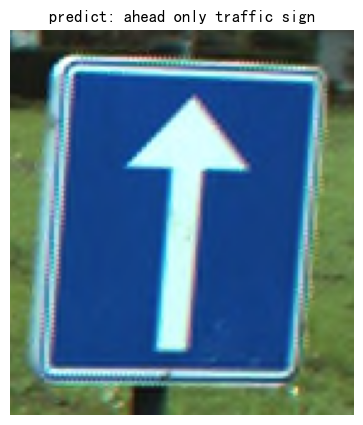

In [15]:
# ================== 测试主流程 ==================
if __name__ == '__main__':
    # 指定测试图片（请改为实际存在的图片路径）
    TEST_IMAGE = '/home/jovyan/work/datasets/6a55d503fdd9153745ce922b-momodel/train/ahead only traffic sign/train_08_00001.png'

    # 检查模型和图片是否存在
    if not MODEL_PATH.is_file():
        raise FileNotFoundError(f'未找到训练得到的模型：{MODEL_PATH}')

    image_path = Path(TEST_IMAGE)
    if not image_path.is_file():
        raise FileNotFoundError(f'未找到测试图片：{image_path}')

    # 读取图片（兼容中文路径）
    encoded = np.fromfile(str(image_path), dtype=np.uint8)
    image = cv2.imdecode(encoded, cv2.IMREAD_UNCHANGED)
    if image is None:
        raise ValueError(f'图片无法读取：{image_path}')

    # 预测
    predicted_label = predict(image)
    expected_label = normalize_label(image_path.parent.name)   # 目录名作为真实标签（仅供自检）
    print('测试图片：', image_path)
    print('目录标签（仅供自检）：', expected_label)
    print('模型预测：', predicted_label)

    # 显示图片
    # 转换颜色空间以正确显示
    if image.ndim == 2:
        display = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    elif image.shape[2] == 3:
        display = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    elif image.shape[2] == 4:
        display = cv2.cvtColor(image, cv2.COLOR_BGRA2RGBA)
    else:
        display = image  # 备用

    plt.figure(figsize=(5, 5))
    plt.imshow(display)
    plt.title(f'predict: {predicted_label}')
    plt.axis('off')
    plt.show()


## 5. 评分方式与提交要求

本赛题使用宏平均F1值作为评价指标，最终成绩计算方式为：

**macro F1-score × 100**

评分时会分别计算25个类别的F1值，再对所有类别进行等权平均。即使某些类别的样本数量较少，也会在最终指标中占据相同权重。


## 6. 平台预测接口与注意事项

平台通过调用`main.py`中的`predict(X)`函数完成逐张图片预测。

`predict(X)`的输入通常为通过`cv2.imread`读取的图像数组，常见格式为BGR三通道。预测程序会自动完成：

1. 输入合法性检查；
2. 灰度、三通道或四通道图片转换；
3. BGR到RGB的色彩空间转换；
4. 图片尺寸统一；
5. 数值归一化；
6. 模型前向推理；
7. 预测类别名称输出。

函数最终返回25个正式交通标志类别名称之一，不返回目标框、坐标、特征向量或完整概率数组。

训练脚本保存的checkpoint应至少包含：

- 模型参数；
- 类别编号与类别名称映射；
- 模型输入尺寸；
- 模型名称；
- 类别数量；
- 最佳内部验证macro F1；
- 对应训练轮次。

正式提交前，应重点确认：

- `classes.txt`与训练目录中的25类完全一致；
- `train.py`和`main.py`使用相同模型结构；
- 训练和预测阶段使用相同的输入尺寸及归一化参数；
- 模型文件已保存到程序配置的正确路径；
- `predict(X)`返回值属于正式25类；
- 返回的类别名称不存在多余空格或拼写错误；
- 程序不读取或依赖验证集、评分集的真实标签。